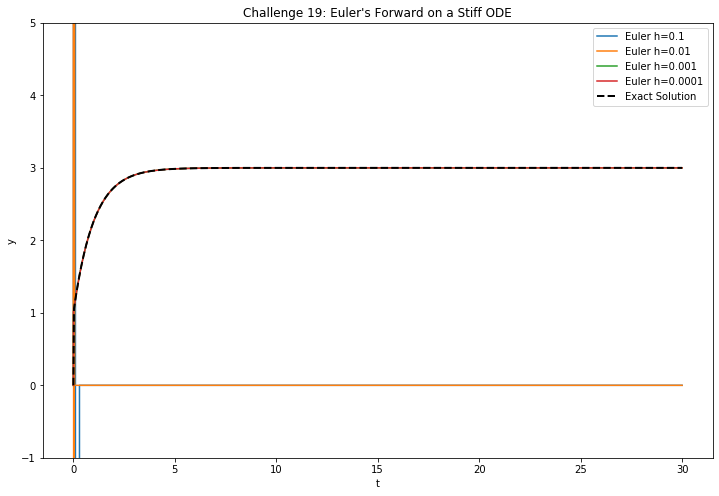

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Define parameters
h_values = [.1, .01, .001, .0001]
t_start, t_end = 0, 30

# Function representing dy/dx = -1000y + 3000 - 2000e^-t
def f(t, y):
    return -1000 * y + 3000 - 2000* np.exp(-t)
#funciton for exact solution
def exact_sol(t):
    return 3 - 0.998 * np.exp(-1000 * t) - 2.0002 * np.exp(-t)

plt.figure(figsize=(12, 8))

for h in h_values:
    num_steps = int((t_end - t_start) / h)
    t_values = np.linspace(t_start, t_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)

    # Initial condition
    y_values[0] = 0  # y(0) = 0

    # Implement Euler's method
    for i in range(num_steps):
        y_next = y_values[i] + h * f(t_values[i], y_values[i])
        
        if abs(y_next) > 1e5:
            y_next = np.nan
            break
        y_values[i + 1] = y_next
        
    plt.plot(t_values, y_values, label=f"Euler h={h}")

#Plot Exact Solution for comparison
t_exact = np.linspace(t_start, t_end, 1000)
plt.plot(t_exact, exact_sol(t_exact), 'k--', label="Exact Solution", linewidth=2)
plt.ylim(-1, 5) # Constrain y-axis to see the stable solutions
plt.xlabel('t')
plt.ylabel('y')
plt.title("Challenge 19: Euler's Forward on a Stiff ODE")
plt.legend(loc='upper right')
plt.show()

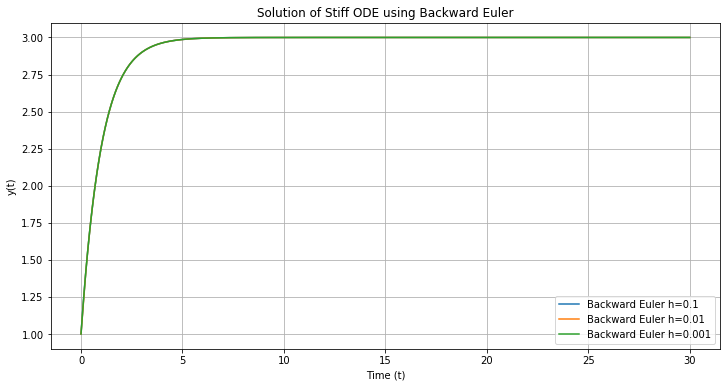

In [18]:
#forward euler method
from scipy.optimize import fsolve

# Define the ODE
def f(t, y):
    return -1000 * y + 3000 - 2000* np.exp(-t)

h_values = [.1, .01, .001]

# Backward Euler method
def backward_euler(f, y0, t0, tf, h):
    t_values = np.arange(t0, tf + h, h)
    y_values = np.zeros_like(t_values)
    y_values[0] = y0
    
    for i in range(1, len(t_values)):
        t_next = t_values[i]
        y_prev = y_values[i - 1]
        
        # Implicit function to solve for y_next
        g = lambda y_next: y_next - y_prev - h * f(t_next, y_next)
        
        # Use previous value as initial guess
        y_values[i] = fsolve(g, y_prev)
        
    return t_values, y_values

# Parameters
y0 = 1
t0 = 0
tf = 30

plt.figure(figsize=(12, 6))
#solve the ODE
for h in h_values:
    t_vals, y_vals = backward_euler(f, y0, t0, tf, h)
    plt.plot(t_vals, y_vals, label=f'Backward Euler h={h}')

# Plot the results
plt.xlabel('Time (t)')
plt.ylabel('y(t)')
plt.title('Solution of Stiff ODE using Backward Euler')
plt.legend()
plt.grid(True)
plt.show()

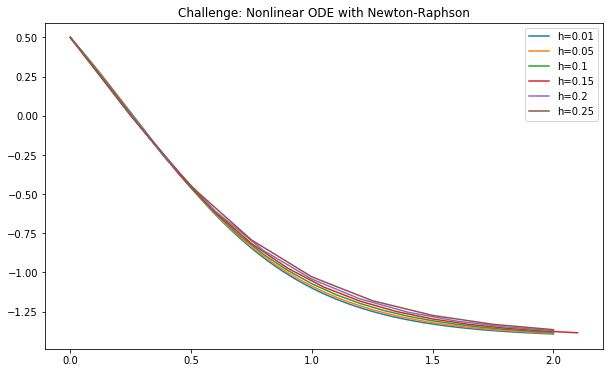

In [20]:
#Newton-Raphson
def f_nonlinear(t, y):
    return y**2 - 2

def backward_euler_newton(f, y0, t0, tf, h):
    t_values = np.arange(t0, tf + h, h)
    y_values = np.zeros_like(t_values)
    y_values[0] = y0
    
    for i in range(1, len(t_values)):
        t_next = t_values[i]
        y_prev = y_values[i - 1]
        
        y_curr = y_prev
        for _ in range(100):
            # g(y_next) = y_next - y_prev - h*f(t_next, y_next)
            g = y_curr - y_prev - h * (y_curr**2 - 2)
            # g'(y_next) = 1 - h*f'(y_next) -> derivative of y^2-2 is 2y
            dg = 1 - h * (2 * y_curr)
            
            y_next = y_curr - g / dg
            
            # Check convergence
            if abs(y_next - y_curr) < 1e-6:
                break
            y_curr = y_next
            
        y_values[i] = y_next
        
    return t_values, y_values

#plot the results
plt.figure(figsize=(10, 6))
for h in [0.01, 0.05, 0.1, 0.15, 0.2, 0.25]:
    t, y = backward_euler_newton(f_nonlinear, y0=0.5, t0=0, tf=2, h=h)
    plt.plot(t, y, label=f'h={h}')

plt.title("Challenge: Nonlinear ODE with Newton-Raphson")
plt.legend()
plt.show()